Saved to ../figures/timeline_banner.png


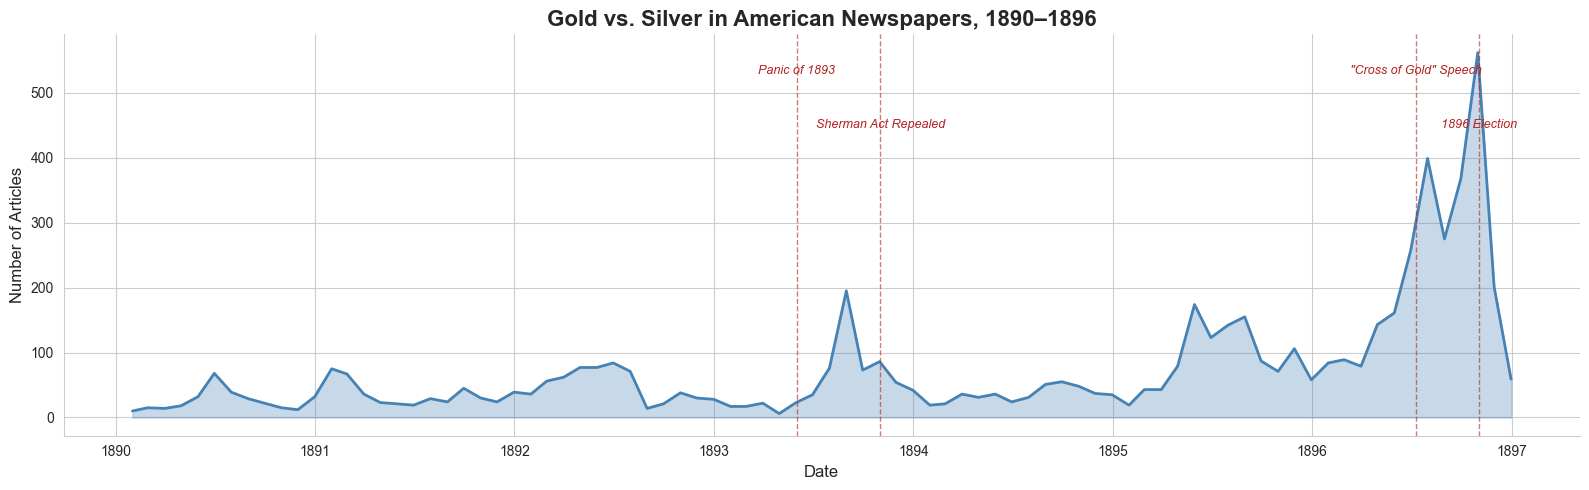

In [18]:
# Recreate the monthly timeline as a polished banner image for the README
fig, ax = plt.subplots(figsize=(16, 5))

monthly = valid_dates.set_index('date_parsed').resample('ME').size()
ax.fill_between(monthly.index, monthly.values, alpha=0.3, color='steelblue')
ax.plot(monthly.index, monthly.values, color='steelblue', linewidth=2)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Number of Articles', fontsize=12)
ax.set_title('Gold vs. Silver in American Newspapers, 1890–1896', fontsize=16, fontweight='bold')

# Mark key events with cleaner styling
events = {
    '1893-06-01': ('Panic of 1893', 0.92),
    '1893-11-01': ('Sherman Act Repealed', 0.78),
    '1896-07-09': ('"Cross of Gold" Speech', 0.92),
    '1896-11-03': ('1896 Election', 0.78),
}
for date_str, (label, y_frac) in events.items():
    ax.axvline(pd.Timestamp(date_str), color='firebrick', linestyle='--', alpha=0.6, linewidth=1)
    ax.text(pd.Timestamp(date_str), ax.get_ylim()[1] * y_frac, label,
            ha='center', va='top', fontsize=9, color='firebrick', fontstyle='italic')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

save_path = "../figures/timeline_banner.png"
import os
os.makedirs(os.path.dirname(save_path), exist_ok=True)
fig.savefig(save_path, dpi=200, bbox_inches='tight', facecolor='white')
print(f"Saved to {save_path}")
plt.show()

# 02 — Explore Filtered Data

EDA on the gold/silver articles filtered from American Stories.
Goals: understand the volume, distribution, and content of our filtered articles
before running stance detection.

**Input**: `data/american_stories/filtered_articles.parquet`

In [7]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [8]:
df = pd.read_parquet("../data/american_stories/filtered_articles.parquet")

# Parse matched_keywords back to lists if stored as pipe-delimited string
if df['matched_keywords'].dtype == object and isinstance(df['matched_keywords'].iloc[0], str):
    df['matched_keywords'] = df['matched_keywords'].str.split('|')

print(f"Total articles: {len(df):,}")
df.head()

Total articles: 6,179


,article_id,newspaper_name,edition,date,page,headline,byline,article,lccn,year,matched_keywords
0,12_1890-04-23_p2_sn84027718_00271762707_189004...,Connecticut western news.,01,1890-04-23,p2,WINDOWS SILVER BILL.\n\nThe Secretary of the T...,,What He Says It Will Accomplish If It\n\n Beco...,sn84027718,1890,free coinage|silver coinage
1,18_1890-12-10_p2_sn85032938_00211105550_189012...,Arizona weekly journal-miner.,01,1890-12-10,p2,FROM MoNpAYs DAILY.,,\\n\n Coles A Bsshiord is in Phenix.\n\n K. Ba...,sn85032938,1890,free coinage
2,3_1890-06-22_p3_sn84025968_00280769320_1890062...,Los Angeles herald.,01,1890-06-22,p3,Silver Coinage Approyed.,,"SPOKANE FALLS, June 2l.-The bank\ners' associa...",sn84025968,1890,coinage of silver
3,32_1890-06-22_p3_sn84025968_00280769320_189006...,Los Angeles herald.,01,1890-06-22,p3,THE SILVER BILL.\n1t Remains With the Coinage\...,,nays were ordered upon McKinleys mo-\nton to t...,sn84025968,1890,free coinage
4,28_1890-04-08_p1_sn86063206_00383341024_189004...,The Delta independent.,01,1890-04-08,p1,"CONGRESSIONAL.\n\nMONDAY, MARCH 81.",,CONGRESSIONAL.\nMONDAY. MARCH 81.\n\n\nSKSArE....,sn86063206,1890,coinage of silver


## Basic Statistics

Article length (characters):
count    6179.000000
mean     2186.312996
std      1853.664100
min       100.000000
25%       642.000000
50%      1633.000000
75%      3259.000000
max      8740.000000
Name: article_length, dtype: float64


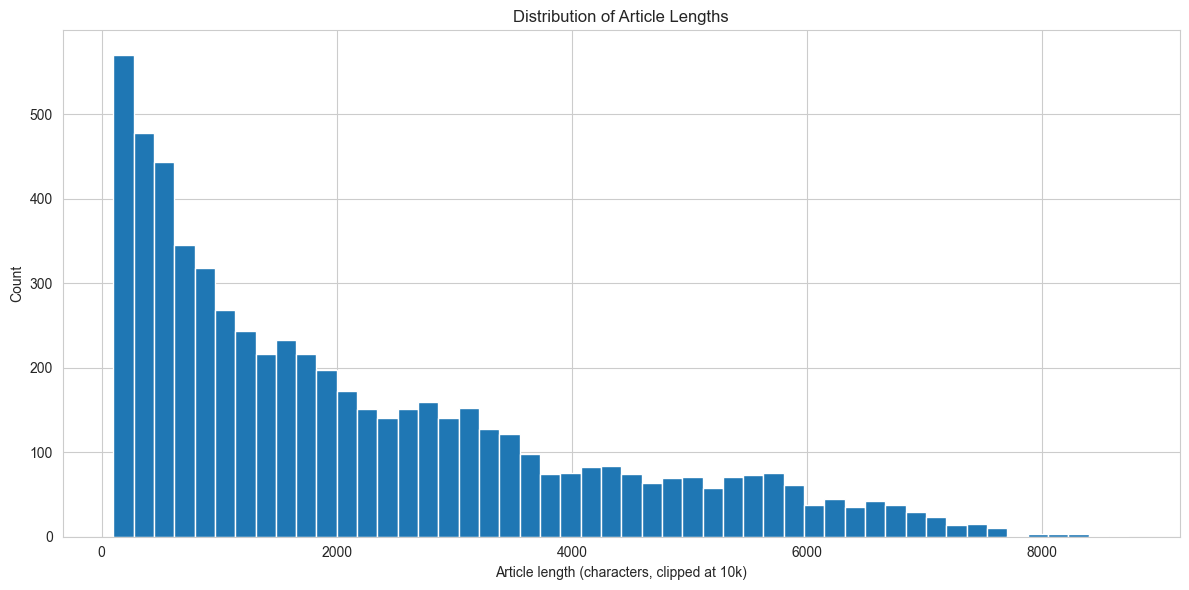

In [9]:
# Article length distribution
df['article_length'] = df['article'].str.len()

print("Article length (characters):")
print(df['article_length'].describe())

fig, ax = plt.subplots()
df['article_length'].clip(upper=10000).hist(bins=50, ax=ax)
ax.set_xlabel('Article length (characters, clipped at 10k)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Article Lengths')
plt.tight_layout()
plt.show()

In [10]:
# Number of keyword matches per article
df['n_keywords'] = df['matched_keywords'].apply(len)

print("Keywords matched per article:")
print(df['n_keywords'].value_counts().sort_index())

Keywords matched per article:
n_keywords
7       50
8      151
9       92
10     158
11    1510
      ... 
89       1
92       2
94       2
95       1
97       1
Name: count, Length: 77, dtype: int64


## Articles Over Time

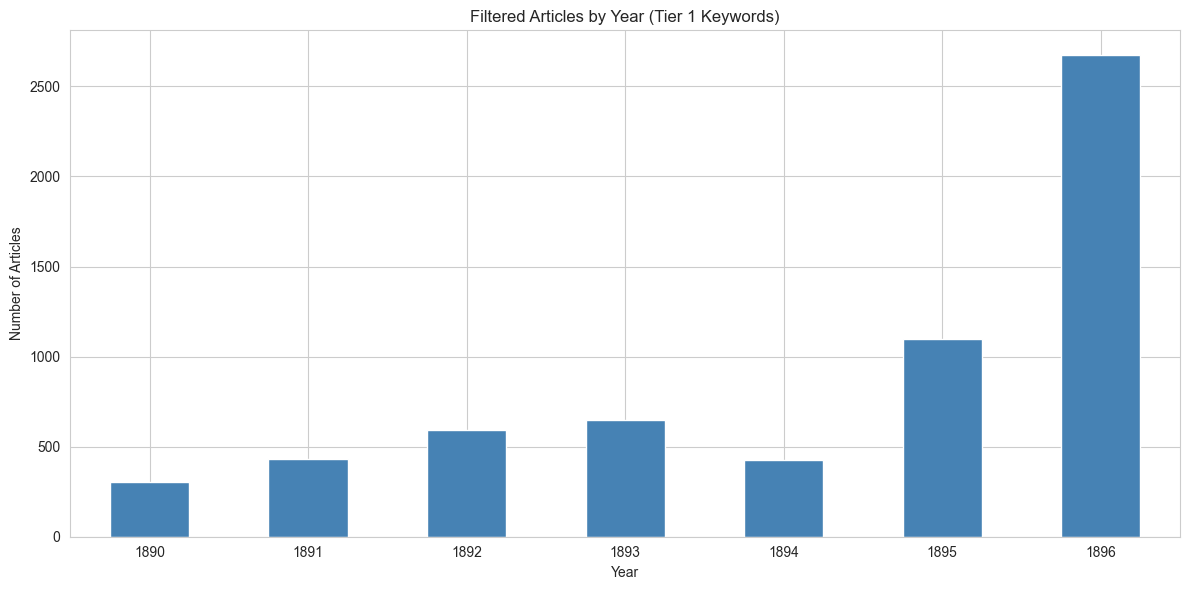

In [11]:
# Articles per year
year_counts = df['year'].value_counts().sort_index()

fig, ax = plt.subplots()
year_counts.plot(kind='bar', ax=ax, color='steelblue')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Articles')
ax.set_title('Filtered Articles by Year (Tier 1 Keywords)')
ax.set_xticklabels(year_counts.index, rotation=0)
plt.tight_layout()
plt.show()

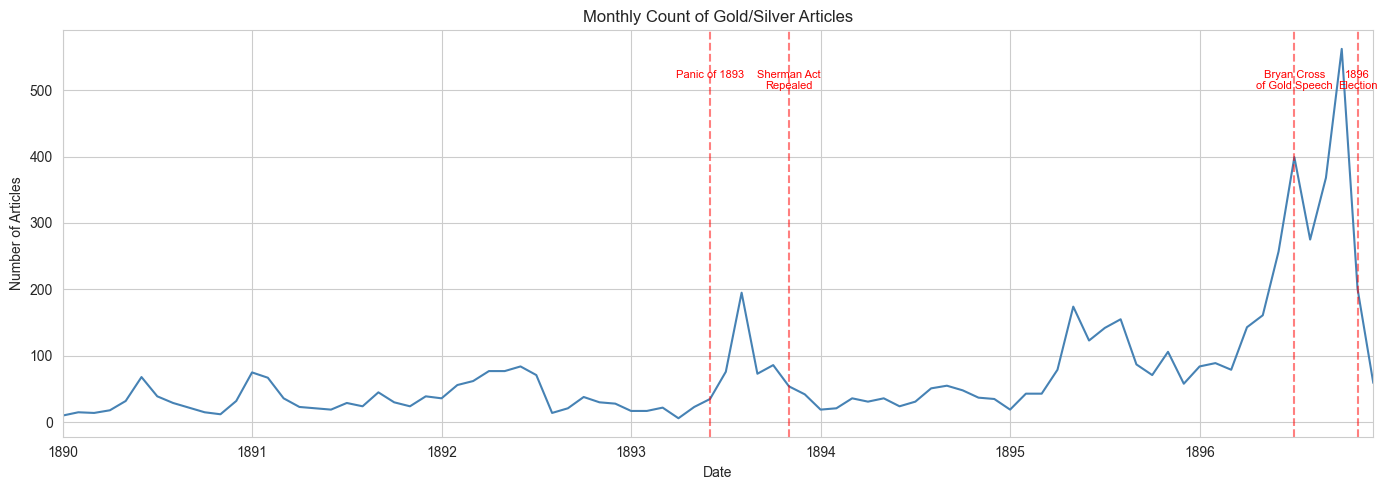

In [12]:
# Try to parse dates for finer-grained time series
df['date_parsed'] = pd.to_datetime(df['date'], errors='coerce')
valid_dates = df.dropna(subset=['date_parsed'])

if len(valid_dates) > 0:
    monthly = valid_dates.set_index('date_parsed').resample('ME').size()
    
    fig, ax = plt.subplots(figsize=(14, 5))
    monthly.plot(ax=ax, color='steelblue')
    ax.set_xlabel('Date')
    ax.set_ylabel('Number of Articles')
    ax.set_title('Monthly Count of Gold/Silver Articles')
    
    # Mark key events
    events = {
        '1893-06-01': 'Panic of 1893',
        '1893-11-01': 'Sherman Act\nRepealed',
        '1896-07-01': 'Bryan Cross\nof Gold Speech',
        '1896-11-01': '1896\nElection',
    }
    for date_str, label in events.items():
        ax.axvline(pd.Timestamp(date_str), color='red', linestyle='--', alpha=0.5)
        ax.text(pd.Timestamp(date_str), ax.get_ylim()[1] * 0.9, label,
                ha='center', va='top', fontsize=8, color='red')
    
    plt.tight_layout()
    plt.show()
else:
    print("Could not parse dates. Check date format in the data.")

## Keyword Frequency

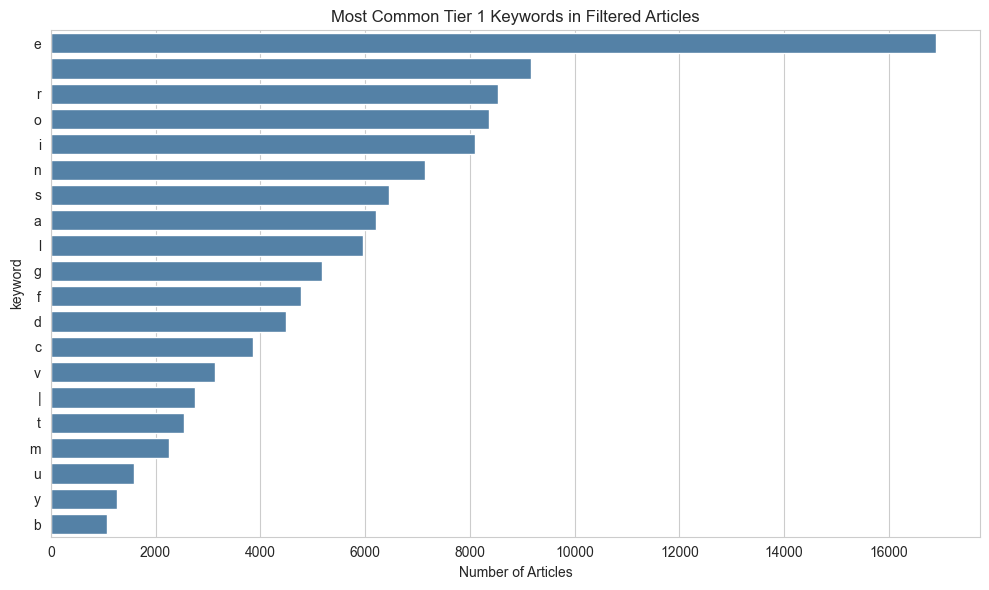

In [13]:
# Most common keywords across all articles
all_kw = [kw for kw_list in df['matched_keywords'] for kw in kw_list]
kw_counts = Counter(all_kw).most_common(20)

kw_df = pd.DataFrame(kw_counts, columns=['keyword', 'count'])

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=kw_df, y='keyword', x='count', ax=ax, color='steelblue')
ax.set_title('Most Common Tier 1 Keywords in Filtered Articles')
ax.set_xlabel('Number of Articles')
plt.tight_layout()
plt.show()

## Top Newspapers

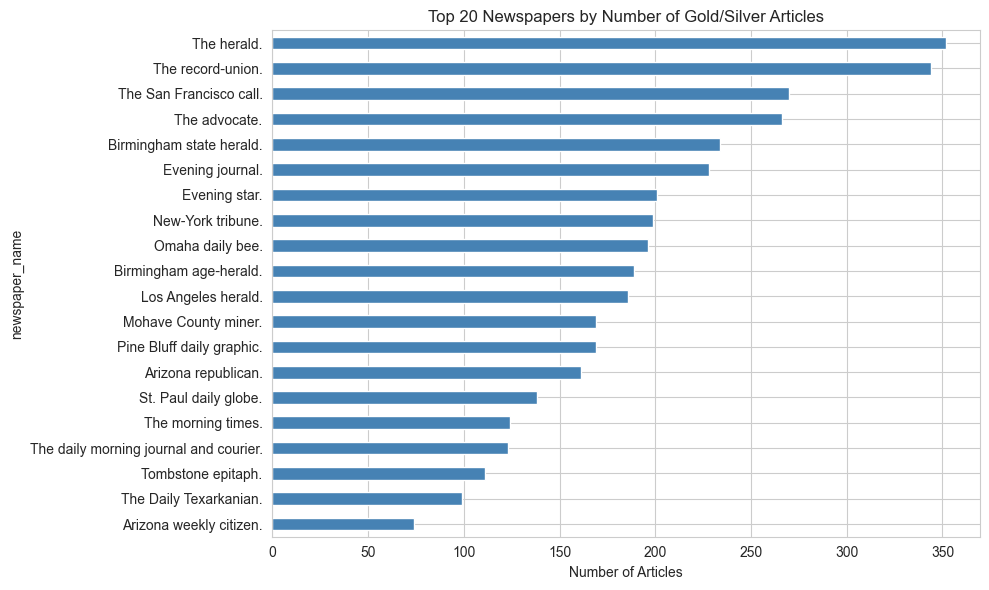

In [14]:
# Most represented newspapers
top_papers = df['newspaper_name'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 6))
top_papers.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Number of Articles')
ax.set_title('Top 20 Newspapers by Number of Gold/Silver Articles')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Sample Articles

Let's read a few articles to get a qualitative sense of the data.

In [15]:
# Show 3 random articles
sample_articles = df.sample(min(3, len(df)), random_state=42)

for i, (_, row) in enumerate(sample_articles.iterrows()):
    print(f"{'='*80}")
    print(f"ARTICLE {i+1}")
    print(f"Newspaper: {row['newspaper_name']}")
    print(f"Date: {row['date']}")
    print(f"Headline: {row['headline']}")
    print(f"Keywords matched: {row['matched_keywords']}")
    print(f"\n{row['article'][:1000]}")
    if len(row['article']) > 1000:
        print(f"\n... [{len(row['article']) - 1000} more characters]")
    print()

ARTICLE 1
Newspaper: The American.
Date: 1896-11-20
Headline: Made 10 Respect The Flag.
Keywords matched: sound money|free silver

Father Nugent, Catholic priest In
East Des Moines. Iowa, was compelled
to run up the stars and stripes last
Friday night.


Up to July Father Nugent was
strong gold man, but returning from
two months sojourn in Wyoming
and Colorado In September, he be-
came radical free silverite and at
tempted to reply to Archbishop Ire
land, which attracted much attention.


1t was alleged here that western
money caused Nugent to change. His
speeches In Iowa and Illinois have been
the most bitter, and he was compelled
by his own church to quit the stump.


He would not concede McKinley's
election until the last moment, and
said that IL had been brought about
by fraud, and that Bryan would be
seated II war was necessary, to ac-
complish it, and that he would be the
first to enter the ranks.


The sound money democrats and the
republicans held monster ratification
Friday ev

## Data Quality Checks

In [16]:
# Missing values
print("Missing values:")
print(df.isnull().sum())
print(f"\nEmpty article text: {(df['article'].str.len() == 0).sum()}")
print(f"Empty newspaper_name: {(df['newspaper_name'].str.len() == 0).sum()}")
print(f"Empty LCCN: {(df['lccn'].str.len() == 0).sum()}")

Missing values:
article_id          0
newspaper_name      0
edition             0
date                0
page                0
headline            0
byline              0
article             0
lccn                0
year                0
matched_keywords    0
article_length      0
n_keywords          0
date_parsed         0
dtype: int64

Empty article text: 0
Empty newspaper_name: 0
Empty LCCN: 5


In [17]:
# Check for potential OCR noise: articles that are very short or repetitive
print(f"Articles < 200 chars: {(df['article_length'] < 200).sum()}")
print(f"Articles < 500 chars: {(df['article_length'] < 500).sum()}")
print(f"Articles > 5000 chars: {(df['article_length'] > 5000).sum()}")

Articles < 200 chars: 309
Articles < 500 chars: 1206
Articles > 5000 chars: 679


## Save Timeline Figure for README